# Train on mouse brain data

This could take several hours. The trained model is provided, which can be used to try the interpretation part without training again.

In [2]:
import os
import sys
sys.path.append("../")
device = "cuda"
import importlib

In [3]:
import scanpy as sc
import squidpy as sq
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
import gc
import sklearn.metrics
import torch

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
c:\Users\lshh\miniconda3\envs\py313_torch291_cuda130\Lib\site-packages\spatialdata\_core\query\relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = parti

In [4]:
avg_contrib_df = pd.read_csv("saved_results/mmbrain_avg_contrib_by_scale.csv", index_col=0)
contrib_df = pd.read_csv("saved_results/mmbrain_contrib_by_scale.csv", index_col=0)

tonsil_contrib_df = pd.read_csv("saved_results/tonsil_avg_contrib_by_scale.csv", index_col=0)
hgsc_contrib_df = pd.read_csv("saved_results/hgsc_avg_contrib_by_scale.csv", index_col=0)
crc_contrib_df = pd.read_csv("saved_results/crc_avg_contrib_by_scale.csv", index_col=0)

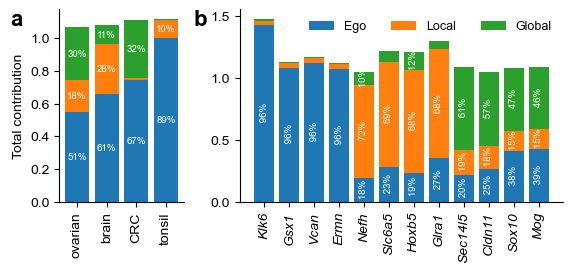

In [ ]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.5, 2.5))
gs = GridSpec(1, 2, width_ratios=[1.15, 3.], hspace=.15, wspace=.25, figure=fig)
axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

full_df = pd.DataFrame(index = ['ovarian', 'brain', 'CRC', 'tonsil'],
                       columns=['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct'])

full_df.loc['brain'] = avg_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
full_df.loc['ovarian'] = hgsc_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
full_df.loc['CRC'] = crc_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
full_df.loc['tonsil'] = tonsil_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]

df = full_df[['ego', 'local', 'global']]

ax = axes[0]
df = full_df
ax.bar(
    x=np.arange(df.shape[0]),
    height=df['ego'],
    label='Ego',
    color='#1f77b4'
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['local'],
    bottom=df['ego'],
    label='Local',
    color='#ff7f0e'
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['global'],
    bottom=df['ego'] + df['local'],
    label='Global',
    color='#2ca02c'
)

for x, y, s in zip(range(df.shape[0]), df['ego'] / 2, full_df['ego_pct']):
    if s < 0.05:
        continue
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center'
    )

for x, y, s in zip(range(df.shape[0]), (2 * df['ego'] + df['local']) / 2, full_df['local_pct']):
    if s < 0.05:
        continue
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center'
    )

for x, y, s in zip(range(df.shape[0]), (2 *df['ego'] + 2 * df['local'] + df['global']) / 2, full_df['global_pct']):
    if s < 0.05:
        continue
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center'
    )

ax.set_ylabel('Total contribution', fontsize=10)
# ax.legend(bbox_to_anchor=(2., -0.05), loc='lower right', frameon=False, fontsize=9)

ax.set_xticks(np.arange(len(full_df.index)))
ax.set_xticklabels([tissue for tissue in full_df.index.tolist()], rotation=90, va='center', ha='right', rotation_mode='anchor')

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)


# top 4 genes of each scale
top = 4
top_ego = contrib_df.sort_values('ego_pct', ascending=False).iloc[:top].index.tolist()
top_local = contrib_df.sort_values('local_pct', ascending=False).iloc[:top].index.tolist()
top_global = contrib_df.sort_values('global_pct', ascending=False).iloc[:top].index.tolist()

ax = axes[1]
full_df = contrib_df.loc[top_ego + top_local + top_global][['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
df = full_df[['ego', 'local', 'global']]
ax.bar(
    x=np.arange(df.shape[0]),
    height=df['ego'],
    label='Ego',
    color='#1f77b4'
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['local'],
    bottom=df['ego'],
    label='Local',
    color='#ff7f0e'
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['global'],
    bottom=df['ego'] + df['local'],
    label='Global',
    color='#2ca02c'
)

s_cutoff = 0.1

for x, y, s in zip(range(df.shape[0]), df['ego'] / 2, full_df['ego_pct']):
    if s < s_cutoff:
        continue
    ax.text(
        x = x,
        y = y,
        s = f" {s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center',
        rotation=90,
        rotation_mode='anchor'
    )

for x, y, s in zip(range(df.shape[0]), (2 * df['ego'] + df['local']) / 2, full_df['local_pct']):
    if s < s_cutoff:
        continue
    ax.text(
        x = x,
        y = y,
        s = f" {s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center',
        rotation=90,
        rotation_mode='anchor'
    )

for x, y, s in zip(range(df.shape[0]), (2 *df['ego'] + 2 * df['local'] + df['global']) / 2, full_df['global_pct']):
    if s < s_cutoff:
        continue
    ax.text(
        x = x,
        y = y,
        s = f" {s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center',
        rotation=90,
        rotation_mode='anchor'
    )

ax.legend(loc='upper right', frameon=False, fontsize=9, ncol=3)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)



labels = ['a']
for ax, label in zip([axes[0]], labels):
    ax.text(x = -0.3, y = 1.0, s = label, 
            transform = ax.transAxes,
            fontsize = 16, fontweight = 'bold',
            va = 'top', ha = 'right'
    )


labels = ['b']
for ax, label in zip([axes[1]], labels):
    ax.text(x = -0.1, y = 1.0, s = label, 
            transform = ax.transAxes,
            fontsize = 16, fontweight = 'bold',
            va = 'top', ha = 'right'
    )




# italicize gene names
ax.set_xticks(np.arange(len(top_ego + top_local + top_global)))
ax.set_xticklabels([gene for gene in contrib_df.loc[top_ego + top_local + top_global].index.tolist()], fontstyle='italic', 
                   rotation=90, va='center', ha='right', rotation_mode='anchor')

In [6]:
avg_contrib_df = pd.read_csv("saved_results/mmbrain_avg_contrib_by_scale.csv", index_col=0)
contrib_df = pd.read_csv("saved_results/mmbrain_contrib_by_scale_filtered.csv", index_col=0)

tonsil_contrib_df = pd.read_csv("saved_results/tonsil_avg_contrib_by_scale.csv", index_col=0)
hgsc_contrib_df = pd.read_csv("saved_results/hgsc_avg_contrib_by_scale.csv", index_col=0)
crc_contrib_df = pd.read_csv("saved_results/crc_avg_contrib_by_scale.csv", index_col=0)

In [7]:

palette = ['#B781B8', '#428BA7' , '#8FC968']

C:\Users\lshh\AppData\Local\Temp\ipykernel_24896\3284473979.py:206: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] * 3)
C:\Users\lshh\AppData\Local\Temp\ipykernel_24896\3284473979.py:245: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=90, ha='right', va='center', rotation_mode='anchor')


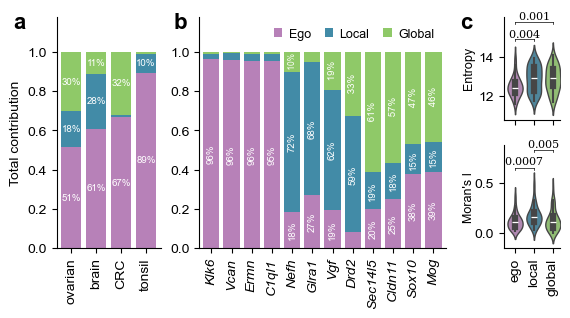

In [ ]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(6.5, 3.))
gs = GridSpec(2, 3, width_ratios=[1.1, 2.4, 0.6], hspace=.25, wspace=.45, figure=fig)
axes = [fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[:, 1]), fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1, 2])]

full_df = pd.DataFrame(index = ['ovarian', 'brain', 'CRC', 'tonsil'],
                       columns=['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct'])

full_df.loc['brain'] = avg_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
full_df.loc['ovarian'] = hgsc_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
full_df.loc['CRC'] = crc_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
full_df.loc['tonsil'] = tonsil_contrib_df.loc['Steamboat', ['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]

df = full_df[['ego', 'local', 'global']]
df = df.div(df.sum(axis=1), axis=0)

ax = axes[0]
ax.bar(
    x=np.arange(df.shape[0]),
    height=df['ego'],
    label='Ego',
    color=palette[0]
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['local'],
    bottom=df['ego'],
    label='Local',
    color=palette[1]
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['global'],
    bottom=df['ego'] + df['local'],
    label='Global',
    color=palette[2]
)

for x, y, s in zip(range(df.shape[0]), df['ego'] / 2, full_df['ego_pct']):
    if s < 0.05:
        continue
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center'
    )

for x, y, s in zip(range(df.shape[0]), (2 * df['ego'] + df['local']) / 2, full_df['local_pct']):
    if s < 0.05:
        continue
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center'
    )

for x, y, s in zip(range(df.shape[0]), (2 *df['ego'] + 2 * df['local'] + df['global']) / 2, full_df['global_pct']):
    if s < 0.05:
        continue
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = 7,
        color = 'white',
        ha = 'center',
        va = 'center'
    )

ax.set_ylim(0, 1.18)
ax.set_ylabel('Total contribution', fontsize=10)
# ax.legend(bbox_to_anchor=(2., -0.05), loc='lower right', frameon=False, fontsize=9)

ax.set_xticks(np.arange(len(full_df.index)))
ax.set_xticklabels([tissue for tissue in full_df.index.tolist()], rotation=90, va='center', ha='right', rotation_mode='anchor')

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)


# top 4 genes of each scale
top = 4
top_ego = contrib_df.sort_values('ego_pct', ascending=False).iloc[:top].index.tolist()
top_local = contrib_df.sort_values('local_pct', ascending=False).iloc[:top].index.tolist()
top_global = contrib_df.sort_values('global_pct', ascending=False).iloc[:top].index.tolist()

ax = axes[1]
full_df = contrib_df.loc[top_ego + top_local + top_global][['ego', 'local', 'global', 'full', 'ego_pct', 'local_pct', 'global_pct']]
df = full_df[['ego', 'local', 'global']]
df = df.div(df.sum(axis=1), axis=0)
ax.bar(
    x=np.arange(df.shape[0]),
    height=df['ego'],
    label='Ego',
    color=palette[0]
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['local'],
    bottom=df['ego'],
    label='Local',
    color=palette[1]
)

ax.bar(
    x=np.arange(df.shape[0]),
    height=df['global'],
    bottom=df['ego'] + df['local'],
    label='Global',
    color=palette[2]
)

s_cutoff = 0.1
s_small = 0.14

for x, y, s in zip(range(df.shape[0]), df['ego'] / 2, full_df['ego_pct']):
    if s < s_cutoff:
        continue
    if s < s_small:
        fontsize = 6
    else:
        fontsize = 7
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = fontsize,
        color = 'white',
        ha = 'center',
        va = 'center',
        rotation=90,
        rotation_mode='anchor'
    )

for x, y, s in zip(range(df.shape[0]), (2 * df['ego'] + df['local']) / 2, full_df['local_pct']):
    if s < s_cutoff:
        continue
    if s < s_small:
        fontsize = 6
    else:
        fontsize = 7
    ax.text(
        x = x,
        y = y,
        s = f"{s * 100:.0f}%",
        fontsize = fontsize,
        color = 'white',
        ha = 'center',
        va = 'center',
        rotation=90,
        rotation_mode='anchor'
    )

for x, y, s in zip(range(df.shape[0]), (2 *df['ego'] + 2 * df['local'] + df['global']) / 2, full_df['global_pct']):
    if s < s_cutoff:
        continue
    if s < s_small:
        fontsize = 6
    else:
        fontsize = 7
    ax.text(
        x = x,
        y = y,
        s = f" {s * 100:.0f}%",
        fontsize = fontsize,
        color = 'white',
        ha = 'center',
        va = 'center',
        rotation=90,
        rotation_mode='anchor'
    )
ax.set_ylim(0, 1.18)
ax.legend(loc='upper right', frameon=False, fontsize=9, ncols=3, columnspacing=1.1, handletextpad=0.5, handlelength=0.7, handleheight=0.7)

for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)

# italicize gene names
ax.set_xticks(np.arange(len(top_ego + top_local + top_global)))
ax.set_xticklabels([gene for gene in contrib_df.loc[top_ego + top_local + top_global].index.tolist()], fontstyle='italic', 
                   rotation=90, va='center', ha='right', rotation_mode='anchor')


ax = axes[2]
k = 50
top_ego = contrib_df.sort_values('ego_pct', ascending=False).iloc[:k].index.tolist()
top_local = contrib_df.sort_values('local_pct', ascending=False).iloc[:k].index.tolist()
top_global = contrib_df.sort_values('global_pct', ascending=False).iloc[:k].index.tolist()

feature_df = pd.DataFrame({'ego': contrib_df.loc[top_ego]['entropy'],
             'local': contrib_df.loc[top_local]['entropy'],
                'global': contrib_df.loc[top_global]['entropy']})

sns.violinplot(data=feature_df, ax=ax, palette=palette, linewidth=1., bw_method=0.5)
ax.set_xticklabels([''] * 3)
ax.set_ylabel("Entropy", fontsize=9)


p = sp.stats.mannwhitneyu(feature_df['local'].dropna(), feature_df['ego'].dropna()).pvalue
x = 0
y = 14.9
dy = 0.1
ax.text(x + 0.5, y + .01, f'${p:.3f}$', 
        ha='center', va='bottom', fontsize=8)
ax.plot([x, x + 1], [y]*2, color='black', lw=.5)
ax.plot([x, x], [y - dy, y], color='black', lw=.5)
ax.plot([x + 1, x + 1], [y - dy, y], color='black', lw=.5)
p = sp.stats.mannwhitneyu(feature_df['ego'].dropna(), feature_df['global'].dropna()).pvalue
x = 0
dx = 2
y = 15.8
ax.text(x + dx/2, y + .01, f'${p:.3f}$', 
        ha='center', va='bottom', fontsize=8)
ax.plot([x, x + dx], [y]*2, color='black', lw=.5)
ax.plot([x, x], [y - dy, y], color='black', lw=.5)
ax.plot([x + dx, x + dx], [y - dy, y], color='black', lw=.5)
ax.set_yticks([12, 14])
ax.set_xlim([-0.6, 2.4])
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)


ax = axes[3]
k = 50
top_ego = contrib_df.sort_values('ego_pct', ascending=False).iloc[:k].index.tolist()
top_local = contrib_df.sort_values('local_pct', ascending=False).iloc[:k].index.tolist()
top_global = contrib_df.sort_values('global_pct', ascending=False).iloc[:k].index.tolist()

morans_i_df = pd.DataFrame({'ego': contrib_df.loc[top_ego]['morans_i'],
             'local': contrib_df.loc[top_local]['morans_i'],
                'global': contrib_df.loc[top_global]['morans_i']})

sns.violinplot(data=morans_i_df, ax=ax, palette=palette, linewidth=1., bw_method=0.5)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, rotation=90, ha='right', va='center', rotation_mode='anchor')
ax.set_ylabel("Moran's I", fontsize=9)

p = sp.stats.mannwhitneyu(morans_i_df['local'].dropna(), morans_i_df['ego'].dropna()).pvalue
ax.text(0.5, 0.66, f'${p:.4f}$', 
        ha='center', va='bottom', fontsize=8)
ax.plot([0, 1], [0.65]*2, color='black', lw=.5)
ax.plot([0, 0], [0.63, 0.65], color='black', lw=.5)
ax.plot([1, 1], [0.63, 0.65], color='black', lw=.5)
p = sp.stats.mannwhitneyu(morans_i_df['local'].dropna(), morans_i_df['global'].dropna()).pvalue
y = 0.825
ax.text(1.5, y + .01, f'${p:.3f}$', 
        ha='center', va='bottom', fontsize=8)
ax.plot([1, 2], [y]*2, color='black', lw=.5)
ax.plot([1, 1], [y - 0.02, y], color='black', lw=.5)
ax.plot([2, 2], [y - 0.02, y], color='black', lw=.5)
ax.set_xlim([-0.6, 2.4])
for pos in ['right', 'top']:
    ax.spines[pos].set_visible(False)


pos = axes[1].get_position()
pos.x0 -= 0.03
axes[1].set_position(pos)
axes[1].set_xlim([-0.6, 11.6])

labels = ['a']
for ax, label in zip([axes[0]], labels):
    ax.text(x = -0.3, y = 1.02, s = label, 
            transform = ax.transAxes,
            fontsize = 16, fontweight = 'bold',
            va = 'top', ha = 'right'
    )


labels = ['b']
for ax, label in zip([axes[1]], labels):
    ax.text(x = -0.05, y = 1.02, s = label, 
            transform = ax.transAxes,
            fontsize = 16, fontweight = 'bold',
            va = 'top', ha = 'right'
    )

labels = ['c']
for ax, label in zip([axes[1]], labels):
    ax.text(x = 1.11, y = 1.02, s = label, 
            transform = ax.transAxes,
            fontsize = 16, fontweight = 'bold',
            va = 'top', ha = 'right'
    )

for ax in axes[2:]:
    ax.yaxis.set_label_coords(-0.5, 0.5)